In [1]:
import pandas as pd
import numpy as np
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
pd.options.display.float_format = '{:,.3f}'.format

pd.options.mode.chained_assignment = None
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid", font_scale = 2.5)
sns.set_context(rc={"lines.markersize": 17, "lines.linewidth": 2})

use_pgf = False
import matplotlib
import matplotlib.ticker as ticker
if use_pgf:
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
    })

import pickle as pkl
from matplotlib import pyplot as plt
plt.rcParams.update({'figure.max_open_warning': 0})

from scipy.stats.stats import pearsonr
from scipy.stats.stats import pearsonr

from functools import reduce

/tmp/ipykernel_33644/2719381697.py:29: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr
/tmp/ipykernel_33644/2719381697.py:30: DeprecationWarning: Please use `pearsonr` from the `scipy.stats` namespace, the `scipy.stats.stats` namespace is deprecated.
  from scipy.stats.stats import pearsonr


In [6]:
plotdir = "../Plots/google/"
seed = 42
cutoff = 100
timespan = 10000
dimension = 300
#tagged = "Tagged"
tagged = "UnTagged"
#ppmi_preprocess = "PPMI"
ppmi_preprocess = "RAW"
#medianImpute = "med"
medianImpute = "na"
#mode = "CompoundAware"
mode = "CompoundAgnostic"
#mode = "Setting"
#dtype="Dense"
dtype="Sparse"
setting = "withSetting"
is_adj = False
if timespan != 0:
    new_plot_col=list(range(1820,2010,timespan))
else:
    new_plot_col=list(range(1820,2010,10))
compound_grouping_value = "three_groups_unequal"
featurefile = "/fs/scratch/users/pageljs/compounding/google/features_{}_{}_{}_{}_{}_{}_{}.csv".format(mode, setting, ppmi_preprocess, tagged, timespan, cutoff, medianImpute)
compoundfile = "/fs/scratch/users/pageljs/compounding/coha/compounds/compounds.pkl"
headfile = "/fs/scratch/users/pageljs/compounding/coha/compounds/heads.pkl"
modfile = "/fs/scratch/users/pageljs/compounding/coha/compounds/modifiers.pkl"

In [7]:
features=pd.read_csv(featurefile, sep="\t")
features['compound_rating']=''
features.loc[features.compositionality>=4,'compound_rating']='high-rated'
features.loc[(features.compositionality>=2) & (features.compositionality<4),'compound_rating']='med-rated'
features.loc[features.compositionality<2,'compound_rating']='low-rated'
features = features[features.compound_rating != "med-rated"]
features = features[features.source == "reddy"]
features["compound"] = features["modifier"] + " " + features["head"]

In [8]:
features

,modifier,head,arith_mean_sim:0,beta:0,comp_freq:0,comp_size:0,comp_tf:0,geom_mean_sim:0,head_family_size:0,head_family_size_new:0,...,avgModifier,stdevModifier,avgHead,stdevHead,compositionality,stdevHeadModifier,is_adj,compound,source,compound_rating
0,end,user,0.409,0.202,"1,305,077.000","175,444,107.000",20.316,0.381,-11.814,-11.269,...,3.867,1.118,4.867,0.340,4.250,0.871,False,end user,reddy,high-rated
1,firing,line,0.145,0.379,"295,120.000","175,444,107.000",18.171,0.143,-8.910,-8.365,...,1.607,1.655,1.893,1.496,1.704,1.717,False,firing line,reddy,low-rated
3,application,form,0.190,0.572,"8,769,710.000","175,444,107.000",23.064,0.190,-8.626,-8.081,...,4.767,0.423,4.862,0.345,4.800,0.476,False,application form,reddy,high-rated
4,snail,mail,0.185,0.204,"19,593.000","175,444,107.000",14.258,0.150,-12.538,-11.993,...,0.600,0.800,4.586,1.099,1.310,1.021,False,snail mail,reddy,low-rated
6,flea,market,0.105,0.545,"229,713.000","175,444,107.000",17.809,0.105,-9.841,-9.296,...,0.379,0.806,4.714,0.839,1.517,1.133,False,flea market,reddy,low-rated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,credit,card,0.288,0.463,"13,521,655.000","175,444,107.000",23.689,0.288,-11.762,-11.217,...,4.667,0.537,4.897,0.305,4.667,0.699,False,credit card,reddy,high-rated
85,parking,lot,0.171,0.360,"8,083,612.000","175,444,107.000",22.947,0.165,-12.061,-11.516,...,4.833,0.373,4.767,0.496,4.700,0.640,False,parking lot,reddy,high-rated
88,speed,limit,0.185,0.352,"2,433,150.000","175,444,107.000",21.214,0.180,-10.799,-10.254,...,4.933,0.249,4.828,0.378,4.828,0.460,False,speed limit,reddy,high-rated
89,swimming,pool,0.210,0.343,"6,040,150.000","175,444,107.000",22.526,0.202,-12.371,-11.826,...,4.800,0.400,4.900,0.300,4.867,0.340,False,swimming pool,reddy,high-rated


In [9]:
features.columns

Index(['modifier', 'head', 'arith_mean_sim:0', 'beta:0', 'comp_freq:0',
       'comp_size:0', 'comp_tf:0', 'geom_mean_sim:0', 'head_family_size:0',
       'head_family_size_new:0', 'head_freq:0', 'head_prod:0', 'head_tf:0',
       'local_mi:0', 'log_comp_freq:0', 'log_head_freq:0',
       'log_head_freq_new:0', 'log_mod_freq:0', 'log_mod_freq_new:0',
       'log_ratio:0', 'mod_family_size:0', 'mod_family_size_new:0',
       'mod_freq:0', 'mod_prod:0', 'mod_tf:0', 'ppmi:0',
       'sim_bw_constituents:0', 'sim_cpf_0:0', 'sim_cpf_100:0', 'sim_cpf_25:0',
       'sim_cpf_50:0', 'sim_cpf_75:0', 'sim_cpf_beta:0', 'sim_with_head:0',
       'sim_with_modifier:0', 'avgModifier', 'stdevModifier', 'avgHead',
       'stdevHead', 'compositionality', 'stdevHeadModifier', 'is_adj',
       'compound', 'source', 'compound_rating'],
      dtype='object')

# Export table of used compounds

In [10]:
compounds_latex_table = features[["modifier", "head", "compositionality", "avgModifier", "avgHead"]]
compounds_latex_table['compound']=compounds_latex_table['modifier']+' '+compounds_latex_table['head']
compounds_latex_table = compounds_latex_table[["compound", "compositionality", "avgHead", "avgModifier"]]
compounds_latex_table = compounds_latex_table.sort_values(by='compositionality')
print(compounds_latex_table.to_latex(index=False))
with open(plotdir + "used_compounds.table.tex", "w") as compounds_latex_table_out:
    compounds_latex_table_out.write(compounds_latex_table.to_latex(index=False))

\begin{tabular}{lrrr}
\toprule
        compound &  compositionality &  avgHead &  avgModifier \\
\midrule
     gravy train &             0.310 &    0.448 &        0.296 \\
      cloud nine &             0.333 &    0.233 &        0.467 \\
     ivory tower &             0.464 &    0.536 &        0.379 \\
     melting pot &             0.538 &    0.481 &        1.000 \\
   silver bullet &             0.667 &    0.552 &        0.519 \\
     smoking gun &             0.714 &    1.000 &        0.714 \\
 monkey business &             0.724 &    1.852 &        0.667 \\
       snake oil &             0.750 &    0.815 &        0.370 \\
      agony aunt &             0.759 &    0.433 &        1.862 \\
        nest egg &             0.778 &    0.500 &        0.786 \\
         rat run &             0.793 &    2.333 &        0.414 \\
       gold mine &             0.815 &    0.704 &        1.379 \\
       swan song &             0.828 &    1.107 &        0.379 \\
        rat race &             0.857

/tmp/ipykernel_33644/1641230388.py:5: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(compounds_latex_table.to_latex(index=False))
/tmp/ipykernel_33644/1641230388.py:7: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  compounds_latex_table_out.write(compounds_latex_table.to_latex(index=False))


# Create plots

In [11]:
to_add_cols = ['compositionality', 'compound_rating']
lmi_cols = 'local_mi:0'
llr_cols = 'log_ratio:0'
llr_prod_cols = 'log_ratio_prod:0'
ppmi_cols = 'ppmi:0'
sim_bw_constituents_cols = 'sim_bw_constituents:0'
sim_with_head_cols = 'sim_with_head:0'
sim_with_modifier_cols = 'sim_with_modifier:0'
head_prod_cols = 'head_prod:0'
mod_prod_cols = 'mod_prod:0'
beta_cols = 'beta:0'
cpf_beta_cols = 'sim_cpf_beta:0'
cpf_25_cols = 'sim_cpf_25:0'
cpf_50_cols = 'sim_cpf_50:0'
cpf_75_cols = 'sim_cpf_75:0'
cpf_100_cols = 'sim_cpf_100:0'
comp_freq_cols = 'comp_freq:0'
mod_freq_cols = 'mod_freq:0'

corr_cols = ["modifier", "head",
             "compositionality", "avgHead", "avgModifier",
             'local_mi:0', 'log_ratio:0', 'ppmi:0', 'sim_bw_constituents:0',
            'sim_with_head:0', 'sim_with_modifier:0', 'head_prod:0', 'mod_prod:0',
            'log_comp_freq:0', 'log_head_freq:0', 'log_mod_freq:0',
            'comp_tf:0', 'head_tf:0', 'mod_tf:0', 'mod_family_size:0', 'head_family_size:0',
            'beta:0' ,'sim_cpf_beta:0', 'sim_cpf_0:0', 'sim_cpf_25:0', 'sim_cpf_50:0', 'sim_cpf_75:0', 'sim_cpf_100:0',
            'comp_freq:0', 'mod_freq:0', 'head_freq:0']
#selected_compounds=['health insurance','silver bullet','melting pot','gold mine','swimming pool','bank account']
#assert (len(lmi_cols)+len(llr_cols)+len(ppmi_cols)+len(sim_bw_constituents_cols)+len(sim_with_head_cols)+len(sim_with_modifier_cols))==(len(features.columns))

In [12]:
year_token_counts = pd.read_csv('../../data/coha_year_token_count.csv')
year_token_counts.columns = ['year', 'tokencount']
if timespan == 10000:
    year_token_counts = year_token_counts.append(year_token_counts.sum(), ignore_index = True)
    year_token_counts = year_token_counts.tail(1)
    year_token_counts[["year"]] = 0
year_token_counts

/tmp/ipykernel_33644/2049384262.py:4: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  year_token_counts = year_token_counts.append(year_token_counts.sum(), ignore_index = True)


,year,tokencount
20,0,491371597


In [13]:
regression_results_temporal = pd.read_csv("../../data/regression_temporal.csv", sep="\t")
regression_results_nontemporal = pd.read_csv("../../data/regression_non_temporal.csv", sep="\t")
regression_results = regression_results_temporal[["modifier", "head", "fitted_values"]]
regression_results.rename(columns = {"fitted_values": "reg_temp"}, inplace = True)
regression_results["reg_nontemp"] = regression_results_nontemporal["fitted_values"]
regression_results['compound']=regression_results['modifier'].str[:-5]+' '+regression_results['head'].str[:-5]
if timespan == 10000:
    regression_results["year"] = 0
else:
    regression_results["year"] = 2000
regression_results = regression_results[["compound", "year", "reg_temp", "reg_nontemp"]]
regression_results = pd.melt(regression_results, id_vars=["year","compound"],
                              value_vars=['reg_temp', 'reg_nontemp'])
regression_results.rename(columns = {"variable": "Feature"}, inplace = True)
regression_results = regression_results[["compound", "year", "value", "Feature"]]
regression_results

,compound,year,value,Feature
0,web site,0,3.513,reg_temp
1,video game,0,3.638,reg_temp
2,balance sheet,0,3.635,reg_temp
3,radio station,0,3.729,reg_temp
4,face value,0,3.657,reg_temp
...,...,...,...,...
81,cotton candy,0,2.684,reg_nontemp
82,insurance company,0,3.054,reg_nontemp
83,loan shark,0,2.490,reg_nontemp
84,news agency,0,3.954,reg_nontemp


In [14]:
corr_df = features[corr_cols]
corr_df = pd.melt(corr_df, id_vars=["modifier", "head"])
corr_df.rename(columns = {"variable": "Feature"}, inplace = True)
corr_df.drop_duplicates(inplace=True)
corr_df = pd.merge(corr_df, features[["head", "modifier", "compound_rating"]], on = ["head", "modifier"])
#corr_df['year'] = pd.to_numeric(corr_df['year'])
corr_df = corr_df.pivot_table(values=['value'], index=['modifier', 'head', 'compound_rating'], columns=['Feature'])
corr_df.columns = corr_df.columns.get_level_values(1)
corr_df.rename(columns = {"comp_freq:0": "compound-count", "head_freq:0": "head-count", "mod_freq:0": "mod-count", 
                               "log_comp_freq:0": "compound-count-log", "log_mod_freq:0": "mod-count-log", "log_head_freq:0": "head-count-log",
                               "comp_tf:0": "compound-tf", "mod_tf:0": "modifier-tf", "head_tf:0": "head-tf",
                               "compositionality": "compound-ratings", "avgHead": "head-ratings", "avgModifier": "modifier-ratings",
                               #"reg_temp": "regr-temp", "reg_nontemp": "regr-nontemp",
                               "sim_bw_constituents:0": "sim-bw-const" ,"sim_with_head:0": "sim-with-head", "sim_with_modifier:0": "sim-with-mod",
                               "beta:0": "beta", "sim_cpf_beta:0": "CPF-beta", "sim_cpf_0:0": "CPF-0" ,"sim_cpf_25:0": "CPF-25", "sim_cpf_50:0": "CPF-50", "sim_cpf_75:0": "CPF-75", "sim_cpf_100:0": "CPF-100",
                               "mod_prod:0": "mod-prod", "head_prod:0": "head-prod",
                               "mod_family_size:0": "mod-family-size", "head_family_size:0": "head-family-size",
                               "local_mi:0": "LMI", "log_ratio:0": "LLR", "ppmi:0": "PPMI"}, inplace=True)
corr_df = corr_df[["compound-ratings", "head-ratings", "modifier-ratings",
                               #"regr-temp", "regr-nontemp",
                               "compound-count", "head-count", "mod-count",
                               "sim-bw-const" ,"sim-with-head", "sim-with-mod", 
                               #"CPF-beta", "CPF-0", "CPF-25", "CPF-50", "CPF-75", "CPF-100", 
                               #"comp-prod", "const-prod", "head-prod", "mod-prod",
                               "head-family-size", "mod-family-size",
                               "LLR", "LMI", "PPMI"]]
#corr_df.reset_index(inplace=True, level = ['compound_rating'])
corr_df

,,Feature,compound-ratings,head-ratings,modifier-ratings,compound-count,head-count,mod-count,sim-bw-const,sim-with-head,sim-with-mod,head-family-size,mod-family-size,LLR,LMI,PPMI
modifier,head,compound_rating,,,,,,,,,,,,,,
acid,test,low-rated,1.222,3.897,0.714,"362,966.000","136,721,067.000","60,360,274.000",0.074,0.186,0.200,-9.657,-11.357,"-3,790,063,519.438","860,307.226",2.370
agony,aunt,low-rated,0.759,0.433,1.862,"1,302.000","962,630.000","45,180.000",0.000,0.008,0.010,-15.583,-19.403,"34,458,367.424","15,338.850",11.781
application,form,high-rated,4.800,4.862,4.767,"8,769,710.000","305,979,276.000","38,274,110.000",0.408,0.179,0.202,-8.626,-12.412,"-251,953,769,319.079","56,651,180.596",6.460
bank,account,high-rated,4.733,4.828,4.867,"4,496,600.000","142,758,861.000","45,449,878.000",0.160,0.146,0.378,-9.952,-11.512,"-99,649,300,212.661","28,544,959.966",6.348
call,center,high-rated,4.655,4.414,4.733,"116,629.000","84,771,515.000","10,896,314.000",0.064,0.171,0.164,-10.509,-14.038,"491,504,562.424","453,879.221",3.892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
speed,limit,high-rated,4.828,4.828,4.933,"2,433,150.000","72,693,956.000","25,083,488.000",0.139,0.226,0.144,-10.799,-12.621,"11,065,407,958.510","17,745,748.666",7.293
swan,song,low-rated,0.828,1.107,0.379,"20,380.000","13,442,797.000","513,697.000",0.145,0.651,0.090,-12.132,-16.543,"-58,358,164,625.583","171,976.102",8.438
swimming,pool,high-rated,4.867,4.900,4.800,"6,040,150.000","17,198,455.000","7,229,077.000",0.071,0.267,0.153,-12.371,-14.627,"-285,926,462,282.737","75,378,010.257",12.479


# Correlations

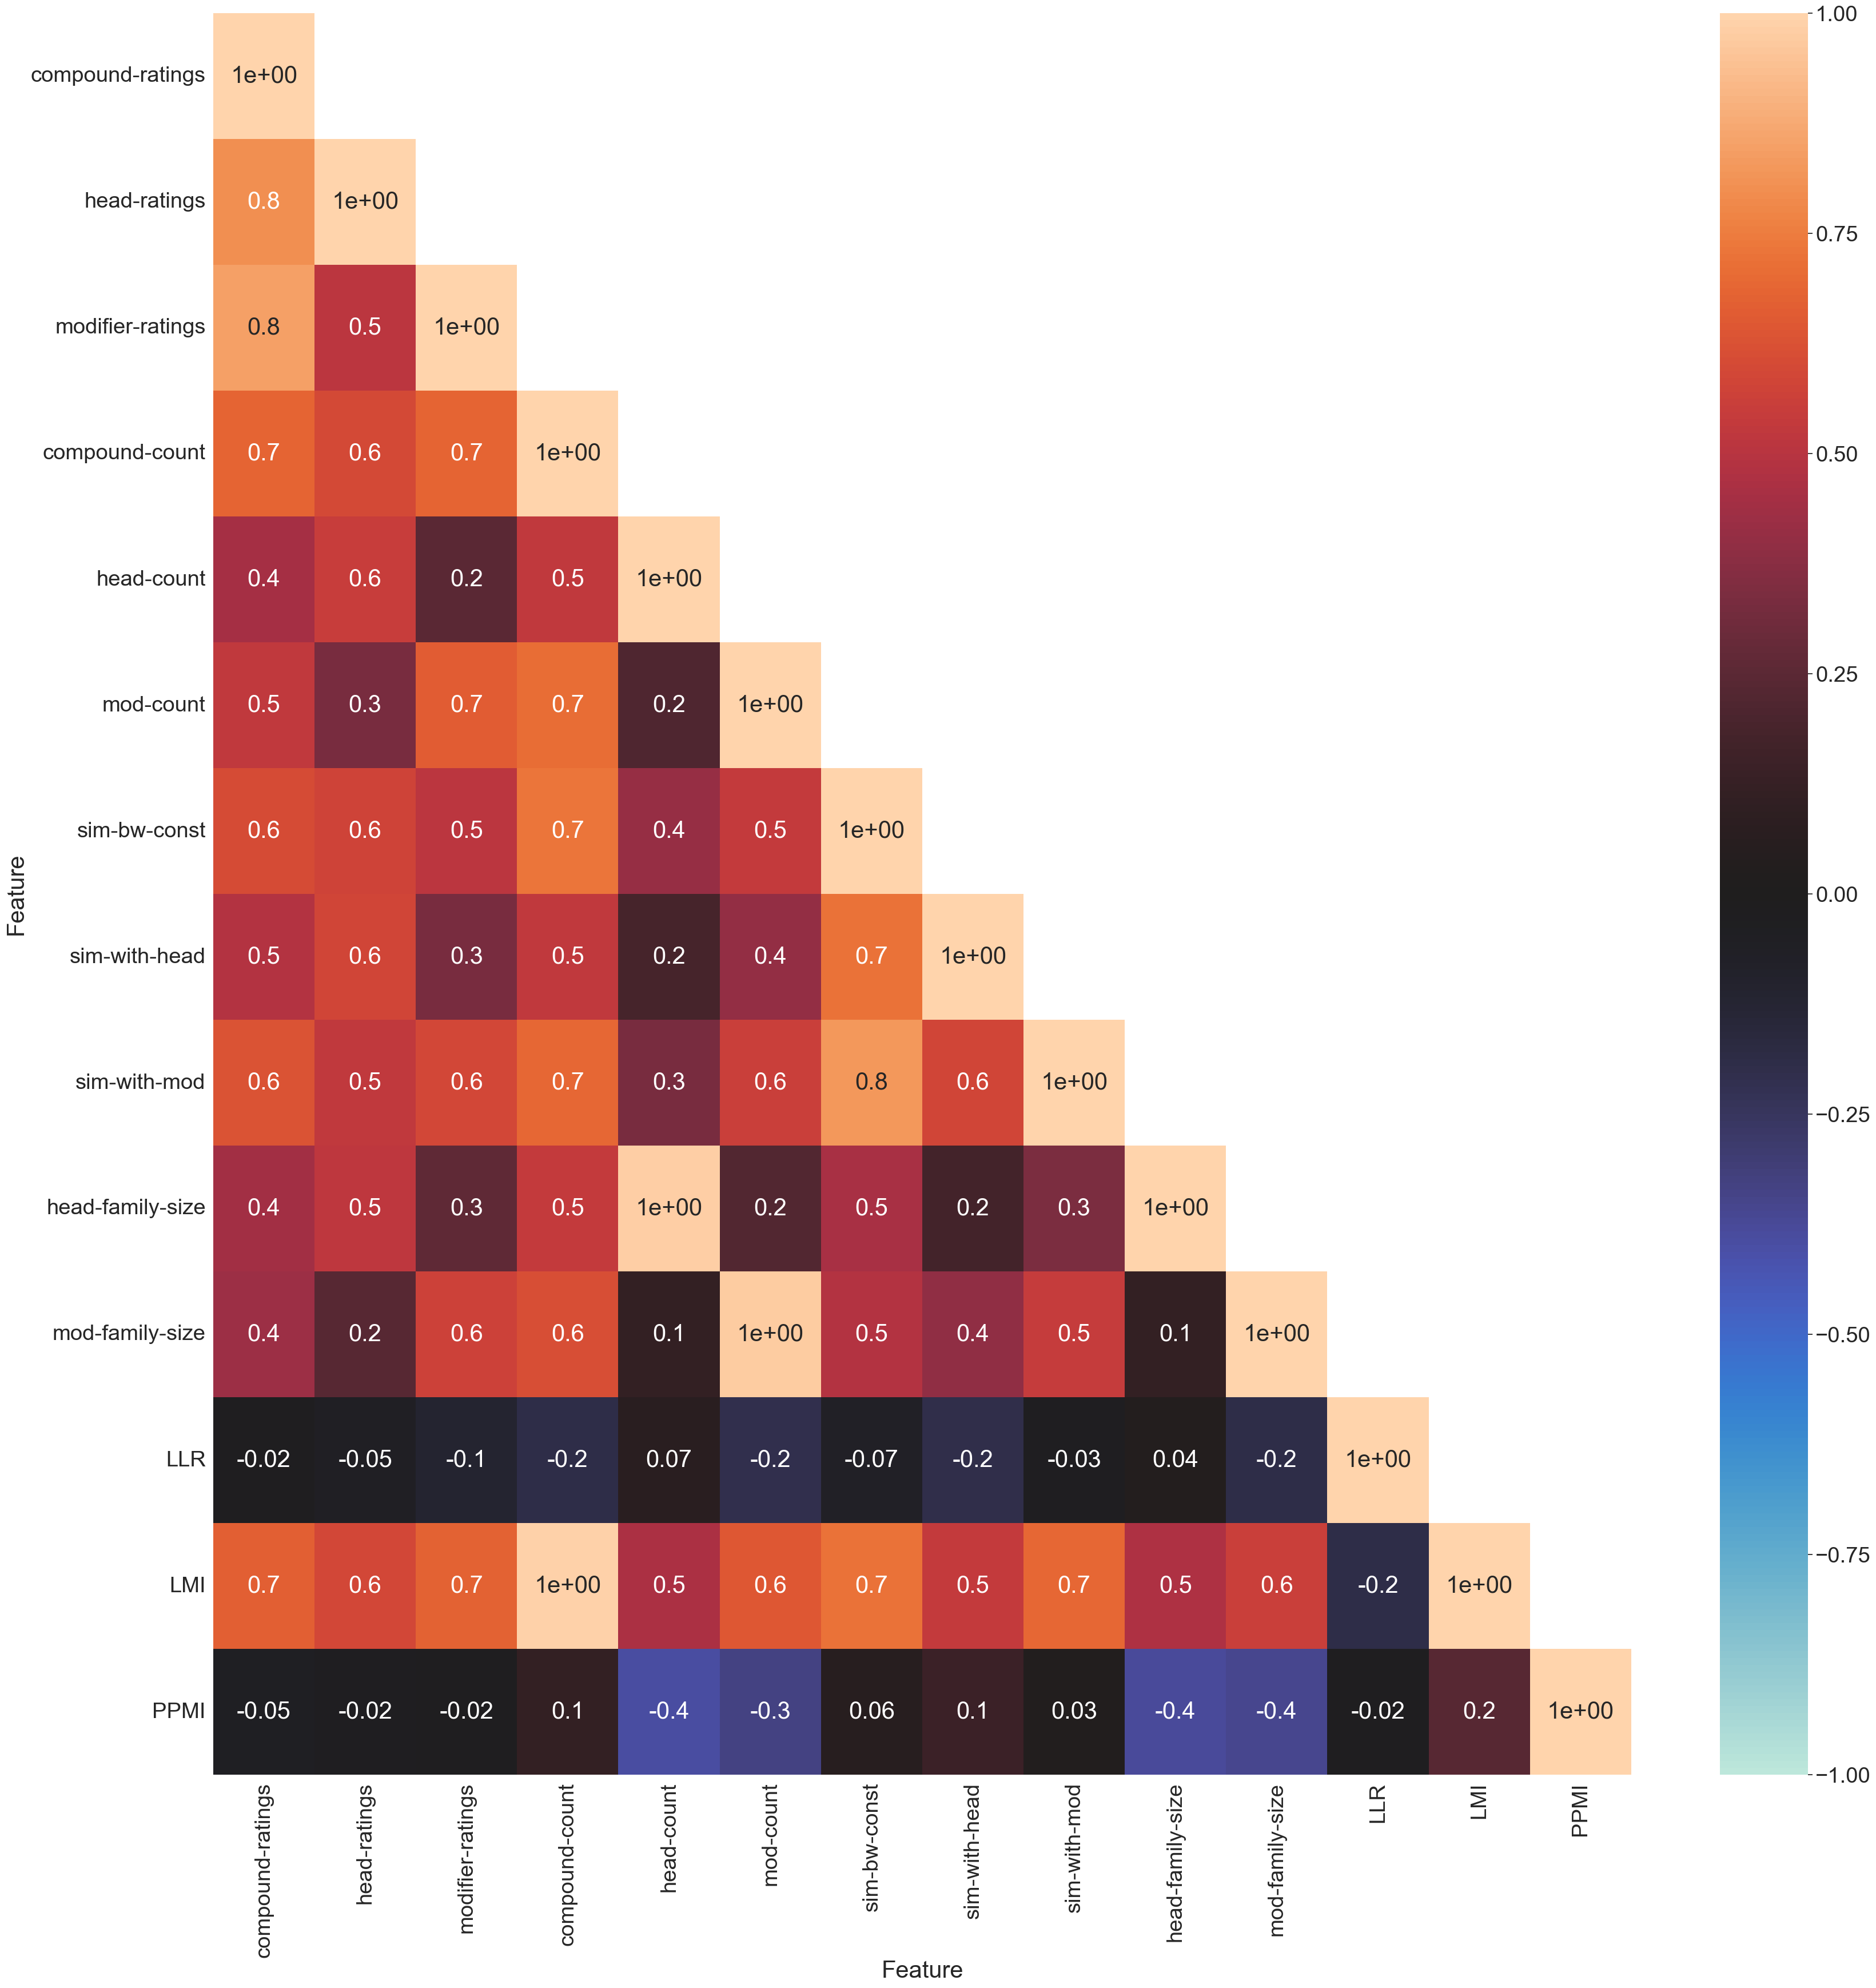

In [15]:
mask = np.zeros_like(corr_df.corr(method='spearman'))
mask[np.triu_indices_from(mask, k=1)] = True
plt.figure(figsize=(40, 40))
g = sns.heatmap(corr_df.corr(method='spearman'), annot=True, fmt=".1", vmin=-1, vmax=1, mask=mask, cbar=True, center=0)
plt.savefig(plotdir+'corr_{}_{}_{}_{}.png'.format(mode, timespan, cutoff, dimension), dpi=300)
#plt.savefig(plotdir+'corr_{}_{}_{}_{}.jpg'.format(mode, timespan, cutoff, dimension), dpi=300)
#plt.savefig(plotdir+'corr_{}_{}_{}_{}.tiff'.format(mode, timespan, cutoff, dimension), dpi=300)
#if use_pgf:
#    plt.savefig(plotdir+'corr_{}_{}_{}_{}.pgf'.format(mode, timespan, cutoff, dimension))

## Correlations per ratings group

### High

In [12]:
corr_df_low = corr_df[corr_df.compound_rating == "low-rated"]
mask = np.zeros_like(corr_df_low.corr(method='spearman'))
mask[np.triu_indices_from(mask, k=1)] = True
plt.figure(figsize=(26, 26))
g = sns.heatmap(corr_df_low.corr(method='spearman'), annot=True, vmin=-1, vmax=1, cmap="YlGnBu", mask=mask, cbar=False)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.png'.format(mode, timespan, cutoff, dimension, "low"), dpi=300)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.jpg'.format(mode, timespan, cutoff, dimension, "low"), dpi=300)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.tiff'.format(mode, timespan, cutoff, dimension, "low"), dpi=300)
if use_pgf:
    plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.pgf'.format(mode, timespan, cutoff, dimension, "low"))

AttributeError: 'DataFrame' object has no attribute 'compound_rating'

### Low

In [ ]:
corr_df_high = corr_df[corr_df.compound_rating == "high-rated"]
mask = np.zeros_like(corr_df_high.corr(method='spearman'))
mask[np.triu_indices_from(mask, k=1)] = True
plt.figure(figsize=(26, 26))
g = sns.heatmap(corr_df_high.corr(method='spearman'), annot=True, vmin=-1, vmax=1, cmap="YlGnBu", mask=mask, cbar=False)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.png'.format(mode, timespan, cutoff, dimension, "high"), dpi=300)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.jpg'.format(mode, timespan, cutoff, dimension, "high"), dpi=300)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.tiff'.format(mode, timespan, cutoff, dimension, "high"), dpi=300)
if use_pgf:
    plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.pgf'.format(mode, timespan, cutoff, dimension, "high"))

# Get statistics about compound frequency distribution per ratings group

In [ ]:
compound_freq_statistics = plot_count_df.drop_duplicates()
compound_freq_statistics = compound_freq_statistics[["compound", "Compositionality Rating", "count"]].groupby(["compound", "Compositionality Rating"]).sum()
compound_freq_statistics

In [ ]:
compound_freq_statistics.groupby(["Compositionality Rating"]).sum()

In [ ]:
compound_freq_statistics.groupby(["Compositionality Rating"]).mean()

In [ ]:
compound_freq_statistics.groupby(["Compositionality Rating"]).std()